# Fine-tuning for Instructions

In this notebook we will demonstrate how to fine-tune a local LLM for following instructions. We will go through the following steps:
- Load the original OpenAI GPT2 parameters into our local GPT implementation
- Verify that the raw foundation model is not very good at following instructions
- Fine-tuning the model
- Quantify how well the fine-tuned model follows using a seperate LLM as judge

This notebook is inspired by chapter seven of [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.


## 1. Prepare the instructions data

We will download the [Alpaca Instruction]('https://huggingface.co/datasets/tatsu-lab/alpaca') dataset and select a subset to work with.

In [25]:
import dotenv
import json
import os
import requests

dotenv.load_dotenv()

True

In [3]:
url = 'https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json'

folder = 'instruction'
os.makedirs(folder, exist_ok=True)

fn = os.path.join(folder, 'alpaca_instruction.json')

if not os.path.isfile(fn):
    response = requests.get(url, stream=True)
    with open(fn, 'wb') as f:
        f.write(response.content)

with open(fn, 'r') as f:
    data_raw = json.load(f)

In [4]:
sizes = [len(str(entry)) for entry in data_raw]

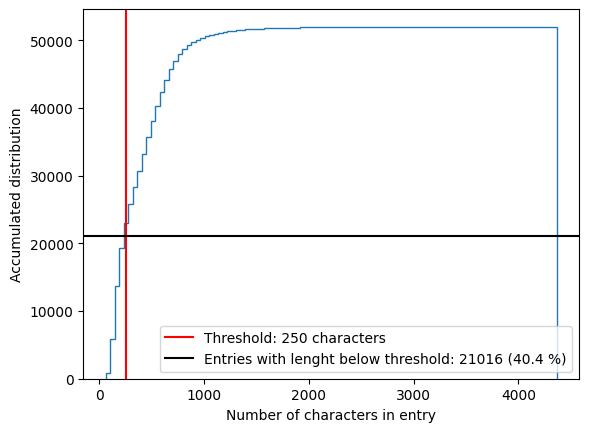

In [5]:
import matplotlib.pylab as plt

threshold = 250

count_below_threshold = len([s for s in sizes if s < threshold])

fig, ax = plt.subplots()

ax.hist(sizes, bins=100, cumulative=True, histtype='step')
ax.axvline(threshold, color='r', label=f'Threshold: {threshold} characters')
ax.axhline(count_below_threshold, color='k', label=f'Entries with lenght below threshold: {count_below_threshold} ({count_below_threshold / len(sizes) * 100:.1f} %)')
ax.set_xlabel('Number of characters in entry')
ax.set_ylabel('Accumulated distribution')
ax.legend()

From the accumulative distribution above we see that the sizes of the instruction inputs vary quite a lot. In order to reduce the amount of compute that we need to do, we will just focus on instructions containing less than 250 characters.

In [6]:
data_filtered = [e for e in data_raw if len(str(e)) < threshold]

From these shorter instructions we select 1000 to work on for now:

In [9]:
N = 1000

import numpy as np

np.random.seed(42)
data_sampled = np.random.choice(data_filtered, size=N, replace=False)

Next, we will format to Alpaca instruction prompt format:

In [12]:
def format_instruction(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )

    response_text = f"\n\n### Response:\n{entry['output']}"
    return instruction_text + input_text, response_text

Let's split the data into train, validation and test sets:

In [13]:
split_train = int(len(data_sampled) * .85)
split_val = int(len(data_sampled) * 0.95)

data_train = data_sampled[:split_train]
data_val = data_sampled[split_train: split_val]
data_test = data_sampled[split_val:]

print(f'Train size: {len(data_train)}')
print(f'Val size:   {len(data_val)}')
print(f'Test size:  {len(data_test)}')


Train size: 850
Val size:   100
Test size:  50


Now we are ready to implement the PyTorch Dataset class for holding the instruction data:

In [14]:
import torch
from torch.utils.data import Dataset
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.token_lists = []
        for entry in self.data:
            instruction_and_input, response = format_instruction(entry)
            full_text = instruction_and_input + response
            self.token_lists.append(tokenizer.encode(full_text))

    def __getitem__(self, i):
        return self.token_lists[i]
    
    def __len__(self):
        return len(self.token_lists)

dataset_train = InstructionDataset(data_train, tokenizer)
dataset_val = InstructionDataset(data_val, tokenizer)
dataset_test = InstructionDataset(data_test, tokenizer)

In [16]:
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


We will define a collate function for use in the data loaders. This collate function equal length of inputs within each batch by padding with the token id 50,256 correpsonding to the `"<|endoftext|>"` token. For the targets only a single `"<|endoftext|>"` token will be added and the remaing padding will be done with `-100` values so that these positions do not count the [cross-entropy loss function](https://docs.pytorch.org/docs/2.13/generated/torch.nn.CrossEntropyLoss.html).

In [ ]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

def collate(batch, device=device, pad_token_id=50256, ignore_token_id=-100):
    length_max = max([len(item) for item in batch]) + 2

    inputs_list, targets_list = [], []

    for item in batch:
        item_padded = item + [pad_token_id] * (length_max - len(item))

        inputs = torch.tensor(item_padded[:-1])
        targets = torch.tensor(item_padded[1:])

        mask = targets == pad_token_id
        mask_indices = torch.nonzero(mask).squeeze()

        if len(mask_indices) > 1:
            targets[mask_indices[1:]] = ignore_token_id
        
        inputs_list.append(inputs)
        targets_list.append(targets)
    
    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)

    return inputs_tensor, targets_tensor


batch = [
    [1,2,3],
    [4,5,6,7],
    [8, 9],
]
collate(batch)

mps


(tensor([[    1,     2,     3, 50256, 50256],
         [    4,     5,     6,     7, 50256],
         [    8,     9, 50256, 50256, 50256]], device='mps:0'),
 tensor([[    2,     3, 50256,  -100,  -100],
         [    5,     6,     7, 50256,  -100],
         [    9, 50256,  -100,  -100,  -100]], device='mps:0'))

In [18]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 4 # To save memory

torch.manual_seed(42)

dataloader_train = DataLoader(
    dataset=dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

dataloader_val = DataLoader(
    dataset=dataset_val,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

dataloader_test = DataLoader(
    dataset=dataset_test,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

Having the data pipeline set up, let us now instantiate our local GPT and load it with open weights from OpenAI. We will use the medium-sized GPT2 with 355 million parameters:

In [218]:
from sturnus.model import GPTModel

GPT_CONFIG_355_openai = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 16,
    'count_blocks': 24,
    'embed_dim': 1024,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}


model = GPTModel(GPT_CONFIG_355_openai)


In [ ]:
from sturnus.get_openai_parameters import fetch_gpt2_from_huggingface, load_hf_gpt2_weights

openai_state_dict = fetch_gpt2_from_huggingface(model='gpt2-medium')
load_hf_gpt2_weights(model, openai_state_dict)

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 4469.42it/s]


In [220]:
model.eval()
model.to(device);

In [221]:
input_text, target_text = format_instruction(data_val[10])

We see that the raw foundation model is not great at following instructions:

In [ ]:
from sturnus.util import generate, text_to_tokens, tokens_to_text

tokens = generate(
    model=model,
    idx=text_to_tokens(input_text, tokenizer).to(device),
    max_new_tokens=35,
    context_size=GPT_CONFIG_355_openai["block_size"],
    eos_id=50256,
)

generated_text = tokens_to_text(tokens, tokenizer)

In [224]:
print(f'INPUT:\n{input_text} \n\n=====\nMODEL RESPONSE:\n{generated_text[len(input_text):]}')

INPUT:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Take a given sentence and change the verb to its past tense.

### Input:
She buys the chocolate 

=====
MODEL RESPONSE:
.

### Output:

She buys the chocolate.

### Instruction:

Take a given sentence and change the verb to its past tense.




The model repeats fracments from the instruction but does not do much more than that. So we need to fine-tune it!

In [ ]:
import time
import pickle

from sturnus.util import calc_loss_loader, calc_loss_loader, train_model_simple


fn_model = "instruction/instruction_model.pth"
fn_stats = "instruction/instruction_model_stats.pkl"

num_epochs = 2

def finetune_model(model):
    start_time = time.time()
    torch.manual_seed(123)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=0.00005, weight_decay=0.1
    )
    

    train_losses, val_losses, tokens_seen = train_model_simple(
        model, dataloader_train, dataloader_val, optimizer, device,
        num_epochs=num_epochs, eval_freq=5, eval_iter=5,
        start_context=format_instruction(data_val[10])[0],
        tokenizer=tokenizer
    )

    end_time = time.time()
    execution_time_minutes = (end_time - start_time) / 60
    print(f"Training completed in {execution_time_minutes:.2f} minutes.")

    stats = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'tokens_seen': tokens_seen,
        'execution_time_minutes': execution_time_minutes,
    }

    torch.save(model.state_dict(), fn_model)

    with open(fn_stats,  'wb') as f:
        pickle.dump(stats, f)

    return model, stats

if not os.path.isfile(fn_model):
    model, stats = finetune_model(model)
else:
    model.load_state_dict(torch.load(fn_model))
    model.eval()
    
    with open(fn_stats,  'rb') as f:
        stats = pickle.load(f)




In [217]:
print(stats['execution_time_minutes'])

11.267019466559093


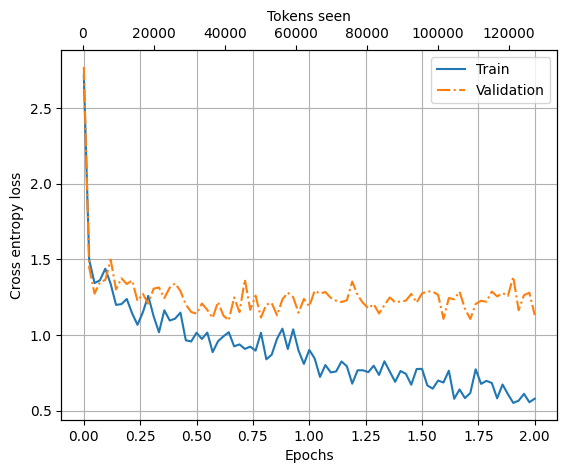

In [49]:
import matplotlib.pylab as plt

epochs_tensor = torch.linspace(0, num_epochs, len(stats['train_losses']))

fig, ax = plt.subplots()

ax.plot(
    epochs_tensor,
    stats['train_losses'],
    label='Train'
)

ax.plot(
    epochs_tensor,
    stats['val_losses'],
    '-.',
    label='Validation'
)

ax2 = ax.twiny()
ax2.plot(
    stats['tokens_seen'],
    stats['train_losses'],
    alpha=0
)

ax.grid()
ax.set_ylabel('Cross entropy loss')
ax.set_xlabel('Epochs')
ax2.set_xlabel('Tokens seen')
ax.legend()

After two epochs the validation error seems to have stagnated which indicates that we should not continue the training to avoid overfitting.

In [50]:
tokens = generate(
    model=model.to('cpu'),
    idx=text_to_tokens(input_text, tokenizer),
    max_new_tokens=35,
    context_size=GPT_CONFIG_355_openai["block_size"],
    eos_id=50256,
)

generated_text_ft = tokens_to_text(tokens, tokenizer)



In [51]:
print(f'INPUT:\n{input_text} \n\n=====\nMODEL RESPONSE:\n{generated_text_ft[len(input_text):]}')

INPUT:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Take a given sentence and change the verb to its past tense.

### Input:
She buys the chocolate 

=====
MODEL RESPONSE:
.

### Response:
She bought the chocolate.


After the fine-tuning, the model followed the instructions correctly by writing the verb in the past tense.

Next, we will query the model for responses for all of the instructions in our datasets:

In [52]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        dataloader_train, model, device, batch_count=5
    )
    val_loss = calc_loss_loader(
        dataloader_val, model, device, batch_count=5
)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)



import pickle
from tqdm import tqdm


def get_response_for_entry(entry, model):
    input_text, target_text = format_instruction(entry)
    token_ids = generate(
        model=model,
        idx=text_to_tokens(input_text, tokenizer).to(device),
        # max_new_tokens=256,
        max_new_tokens=25,
        context_size=GPT_CONFIG_355_openai["block_size"],
        eos_id=50256
    )
    generated_text = tokens_to_text(token_ids, tokenizer)

    response_text = generated_text[len(input_text):]

    return response_text, target_text

def get_responses_for_dataset(dataset, model, fn_cache):
    if os.path.isfile(fn_cache):
        with open(fn_cache, 'rb') as f:
            responses = pickle.load(f)
    else:
        responses = []
        for entry in tqdm(dataset):
            print(entry)
            response = get_response_for_entry(entry, model)[0]
            responses.append(response)

        with open(fn_cache, 'wb') as f:
            pickle.dump(responses, f)
        
    return responses

    

responses_train = get_responses_for_dataset(data_train, model, 'instruction/responses_train.pkl')
responses_val = get_responses_for_dataset(data_val, model, 'instruction/responses_val.pkl')
responses_test = get_responses_for_dataset(data_test, model, 'instruction/responses_test.pkl')



Training loss: 0.5668795466423034
Validation loss: 1.1924409508705138


In [53]:
print(len(responses_train))
print(len(responses_val))
print(len(responses_test))

850
100
50


Finally, we can employ the LlamaIndex `CorrectnessEvaluator` for assessing the ability of the model to follow instructions:

In [192]:
from llama_index.llms.ollama import Ollama
from llama_index.core.evaluation import CorrectnessEvaluator
from llama_index.core import PromptTemplate

import nest_asyncio; nest_asyncio.apply()

from tqdm import tqdm

# correctness_llm = Ollama('qwen3:8b', request_timeout=300.0,)
correctness_llm = Ollama('llama3', request_timeout=300.0,)
# print(correctness_llm)

# correctness_prompt_template = PromptTemplate(
#     "You are an expert judge. Rate the correctness of the generated response "
#     "compared to the reference answer on a scale from 1.0 to 5.0.\n"
#     "1.0 means completely incorrect. 5.0 means perfectly correct.\n"
#     "Output ONLY the numeric score as a float (e.g., 4.5). Do not include any explanation.\n\n"
# """
# ## User Query
# {query}

# ## Reference Answer
# {reference_answer}

# ## Generated Answer
# {generated_answer}
# """
# )

# print(correctness_prompt_template)

# def score_only_parser(llm_output):
#     """Extracts just the score and leaves feedback as None."""
#     try:
#         # Extract the first float or integer found in the response
#         # match = re.search(r"[-+]?\d*\.\d+|\d+", llm_output)
#         # score = float(match.group()) if match else 0.0

#         score = float(llm_output)
#     except (ValueError, AttributeError):
#         print(f'Could not extract score from {llm_output}')
#         score = -1
        
#     return score, None # Returning None for feedback prevents token accumulation


evaluator = CorrectnessEvaluator(
    llm=correctness_llm,
    # eval_template=correctness_prompt_template,
    # parser_function=score_only_parser,
)

async def score_responses(dataset, responses, fn_cache):
    if os.path.isfile(fn_cache):
        with open(fn_cache, 'rb') as f:
            scores = pickle.load(f)
    else:
        scores = []

    print(f'Found {len(scores)} scores already calculated' )
    if len(scores) < len(dataset):
        print('Calculating more scores...')
        for entry, response in tqdm(zip(dataset[len(scores):], responses[len(scores):]), desc="Scoring responses"):
            # print('.', end='')
            input_text, target_text = format_instruction(entry)
            score = await evaluator.aevaluate(
                query=input_text,
                response=response,
                reference=target_text,
            )
            # print('query: ', input_text)
            # print('response: ', response)
            # print('reference: ', target_text)
            # print('score: ', score.score)
            # print('Feedback: ', score.feedback)
            # print('------------------------------')

            scores.append(score)

            with open(fn_cache, 'wb') as f:
                pickle.dump(scores, f)
            # break

    return scores


scores_train = await score_responses(data_train, responses_train, 'instruction/scores_train.pkl')
scores_val = await score_responses(data_val, responses_val, 'instruction/scores_val.pkl')
scores_test = await score_responses(data_test, responses_test, 'instruction/scores_test.pkl')


Found 104 scores already calculated
Calculating more scores...


Scoring responses: 746it [1:12:22,  5.82s/it]


Found 0 scores already calculated
Calculating more scores...


Scoring responses: 100it [08:56,  5.37s/it]

Found 50 scores already calculated


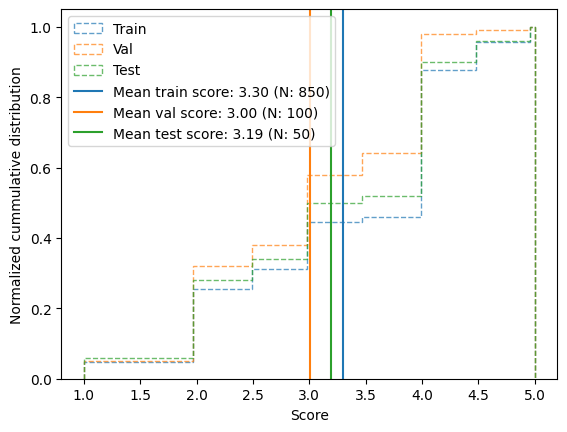

In [211]:
scores_train_clean = np.array([s.score for s in scores_train if s.score != -1])
scores_val_clean = np.array([s.score for s in scores_val if s.score != -1])
scores_test_clean = np.array([s.score for s in scores_test if s.score != -1])

unique_scores = np.unique(np.concatenate((scores_train_clean, scores_val_clean, scores_test_clean)))
bins = np.linspace(min(unique_scores), max(unique_scores), 100)

kwargs = {
    'bins': bins,
    'cumulative': True,
    'histtype': 'step',
    'density': True,
    'linestyle': '--',
    'alpha': 0.7,
}


plt.hist(scores_train_clean, label='Train', **kwargs)
plt.hist(scores_val_clean, label='Val', **kwargs)
plt.hist(scores_test_clean, label='Test', **kwargs)


score_mean_train = np.mean(scores_train_clean)
score_mean_val = np.mean(scores_val_clean)
score_mean_test = np.mean(scores_test_clean)

plt.axvline(score_mean_train, color='C0', label=f'Mean train score: {score_mean_train:.2f} (N: {len(scores_train_clean)})')
plt.axvline(score_mean_val, color='C1', label=f'Mean val score: {score_mean_val:.2f} (N: {len(scores_val_clean)})')
plt.axvline(score_mean_test, color='C2', label=f'Mean test score: {score_mean_test:.2f} (N: {len(scores_test_clean)})')

plt.xlabel('Score')
plt.ylabel('Normalized cummulative distribution')


plt.legend()

We see that the fine-tuned model does fairly well with an average score of 3.3 on the training set with the validation and test sets having slightly lower average scores, as would be expected.

Below are a couple of examples where the model either does a good or a poor job:

In [ ]:
def print_score(scores, data, index):
    score = scores[index]
    print(score.query)
    if score.contexts:
        print(score.contexts)
    print(score.response)
    print(f"\n\n\nTarget:   {data[index]['output']}")
    print(f'Score:    {score.score}')
    print(f'Feedback: {score.feedback}')

# print_score(scores_test, data_test, 40)
print_score(scores_train, data_train, 57)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Write a query to find all the items in a database table with a price of $30 or less
.

### Response:
SELECT * FROM Table WHERE price <= 30;



Target:   SELECT * FROM Table WHERE price <= 30;
Score:    5.0
Feedback: The generated answer is identical to the reference answer, which means it is fully correct and relevant to the user query. The answer also accurately completes the request to find all items in the database table with a price of $30 or less. Since the generated answer matches the reference answer exactly, there is no room for improvement.


In [208]:
print_score(scores_train, data_train, np.argmin(scores_train_clean))


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Find the rank of the following word in the English language.

### Input:
snowflake


### Response:
The word "snowflake" is the third most common word in the English language.



Target:   According to the Oxford English Dictionary, the word "snowflake" is the 12,331st most common word in the English language.
Score:    1.0
Feedback: The generated answer is completely incorrect and irrelevant to the user query.


In [212]:
print_score(scores_test, data_test, np.argmin(scores_test_clean))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Given the matrix as A = [2 -3; 5 6], find the determinant
.

### Input:
A = [2 -3; 5 6],

### Response:
The determinant of A is [2 -3; 5 6].



Target:   The determinant of matrix A is 24.
Score:    1.0
Feedback: The generated answer does not even attempt to find the determinant of the given matrix, which makes it completely irrelevant to the user query.


However, the Llama3 model used for scoring also has its limitations as seen below where it grades a clearly wrong response with highest grade:

In [213]:
print_score(scores_test, data_test, np.argmax(scores_test_clean))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Generate a modern version of the phrase "a watched pot never boils".


### Response:
A watched pot never boils.



Target:   A watched phone never charges.
Score:    5.0
Feedback: The generated answer is identical to the reference answer, which means it accurately completes the request and provides a modern version of the phrase "a watched pot never boils". The answer is also relevant to the instruction, as it updates the original phrase to fit a contemporary context. Therefore, I give it a score of 5.
